# **PCA on Breast Cancer Gene Expression Data**

We start by importing the required libraries and loading the datasets. These include the gene expression matrix, the class labels, and a gene ID-to-name mapping.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

class_df = pd.read_csv('class.tsv', sep='\t', header=None, names=['label'])
expr_df = pd.read_csv('filtered.tsv', sep='\t')
expr_df.columns = expr_df.columns.str.strip()

columns_df = pd.read_csv('columns.tsv', sep='\t', header=None )
columns_df.columns = columns_df.iloc[0]
columns_df = columns_df[1:]
columns_df = columns_df[['ID', 'GeneSymbol']]



We now identify the gene IDs for `XBP1` and `GATA3` using the mapping file. Then we extract their expression values across all 105 samples.

In [2]:
# Get gene IDs for XBP1 and GATA3
xbp1_id = columns_df[columns_df['GeneSymbol'] == 'XBP1']['ID'].values[0]
gata3_id = columns_df[columns_df['GeneSymbol'] == 'GATA3']['ID'].values[0]

print( "IDs for XBP1 and GATA3")
print( xbp1_id )
print( gata3_id )

xbp1_expr = expr_df[str(xbp1_id)]
gata3_expr = expr_df[str(gata3_id)]

IDs for XBP1 and GATA3
4404
4359


Let’s create a scatter plot for the expression values of `XBP1` vs `GATA3`. We color the points based on their class (ER+ in red, ER- in black).

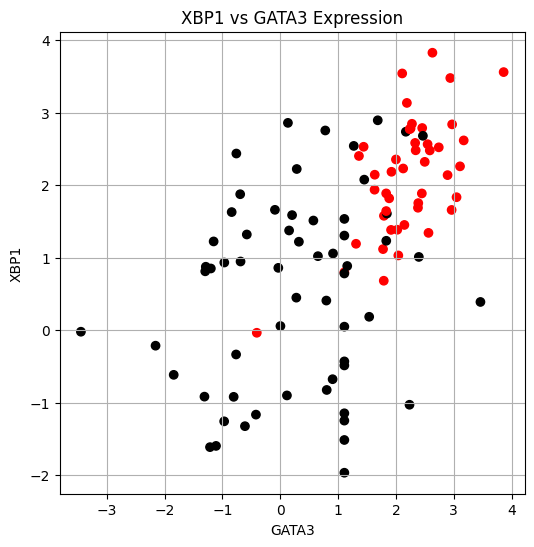

In [3]:
# Create the scatter plot
plt.figure(figsize=(6, 6))
colors = ['black' if lbl == 0 else 'red' for lbl in class_df['label']]
plt.scatter(gata3_expr, xbp1_expr, c=colors)
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('XBP1 vs GATA3 Expression')
plt.grid(True)
plt.show()

In [4]:
# Standardize the dataset (excluding gene_id column)
X = expr_df.values
X_scaled = StandardScaler().fit_transform(X)

We apply PCA and plot the proportion of variance explained by each principal component.

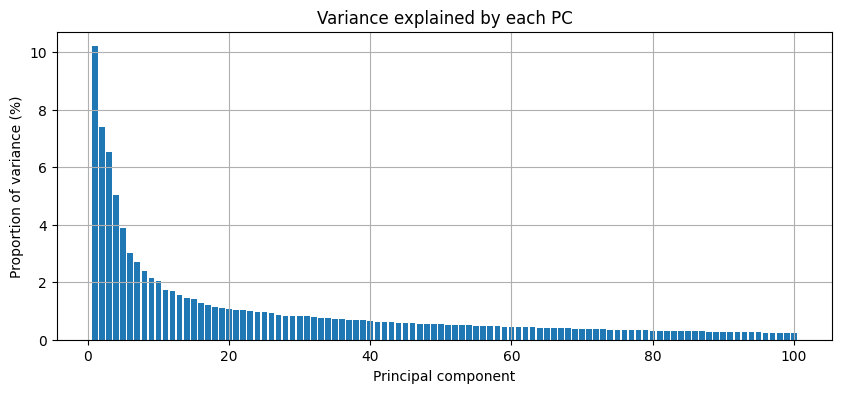

In [5]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot proportion of variance
plt.figure(figsize=(10, 4))
plt.bar(range(1, 101), pca.explained_variance_ratio_[:100] * 100)
plt.xlabel('Principal component')
plt.ylabel('Proportion of variance (%)')
plt.title('Variance explained by each PC')
plt.grid(True)
plt.show()


We now project the data onto the first principal component (PC1). We color-code based on ER status.


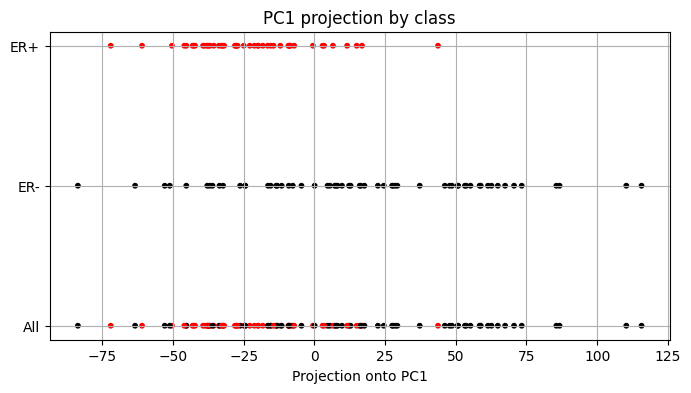

In [6]:
# Project onto PC1
pc1 = X_pca[:, 0]

# Plot projections
plt.figure(figsize=(8, 4))
for i, label in enumerate(['All', 'ER-', 'ER+']):
    if label == 'All':
        indices = range(len(pc1))
    elif label == 'ER-':
        indices = class_df[class_df['label'] == 0].index
    else:
        indices = class_df[class_df['label'] == 1].index
    plt.scatter(pc1[indices], [i]*len(indices), c=np.array(colors)[indices], s=10)

plt.yticks([0, 1, 2], ['All', 'ER-', 'ER+'])
plt.xlabel('Projection onto PC1')
plt.title('PC1 projection by class')
plt.grid(True)
plt.show()